# 00. Choosing the dataset, and pinning down the metric

**Question.** Three public datasets were candidates for this project. Which one actually
carries the three difficulties the project is about, and is the cost metric used here
the same one the published results are measured with?

**Inputs.** The three raw files, each fetched from its own source:

| Candidate | Path |
|---|---|
| APS Failure at Scania Trucks | `data/raw/aps_failure_{training,test}_set.csv` |
| MetroPT-3 | `data/raw/metropt-3/MetroPT3-AirCompressor.csv` |
| Engine Health | `data/raw/engine-health/engine_data.csv` |

**Outputs.** Figures `00_candidate_comparison.png` and `00_state_of_the_art.png`.
Dataset sheets in `docs/dataset_scania.md`, `dataset_metropt3.md`,
`dataset_enginehealth.md`.

**Rule followed here.** Every figure in the dataset sheets is measured on the file, not
copied from the producer's documentation. Two of the three candidates turned out to
have documentation that does not match their contents.

**Only the Scania file is required to run the rest of the project.** The two other
candidates are read here and nowhere else; skip section 2 if they are not on disk.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR, RAW_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 120)

## 1. The retained candidate: APS Scania

Both files are read through `src.data.load`, which locates the header line rather than
skipping a fixed count. The UCI archive carries a 20 line GPL preamble that the Kaggle
mirror does not.

The `na_values` setting is the load-bearing one. Without it the read succeeds with no
error message, every column comes back as text, and the missing-value count returns
zero everywhere.

In [2]:
from src.config import TARGET
from src.data import load

scania = {'training': load('train'), 'test': load('test')}

for name, frame in scania.items():
    rate = frame[TARGET].mean()
    print(f'{name:<9} {frame.shape}  positives {int(frame[TARGET].sum()):>5} '
          f'({rate:.4%})  missing {frame.isna().mean().mean():.4%}')

training  (60000, 171)  positives  1000 (1.6667%)  missing 8.2847%
test      (16000, 171)  positives   375 (2.3438%)  missing 8.3582%


The two positive rates differ, 1.67% against 2.34%, and the difference is real rather
than a rounding artefact. It has one consequence worth carrying forward: a score
measured on a split of the training file is not directly comparable to a score measured
on the test file.

In [3]:
rate = scania['training'].drop(columns=[TARGET]).isna().mean()
print('columns above 65% missing :', int((rate > 0.65).sum()))
print('columns above 50% missing :', int((rate > 0.50).sum()))
print('columns above 20% missing :', int((rate > 0.20).sum()))
print('columns with no gap       :', int((rate == 0).sum()))
print()
print(rate.sort_values(ascending=False).head(8).to_string())

columns above 65% missing : 8
columns above 50% missing : 8
columns above 20% missing : 24
columns with no gap       : 1

br_000    0.821067
bq_000    0.812033
bp_000    0.795667
bo_000    0.772217
cr_000    0.772150
ab_000    0.772150
bn_000    0.733483
bm_000    0.659150


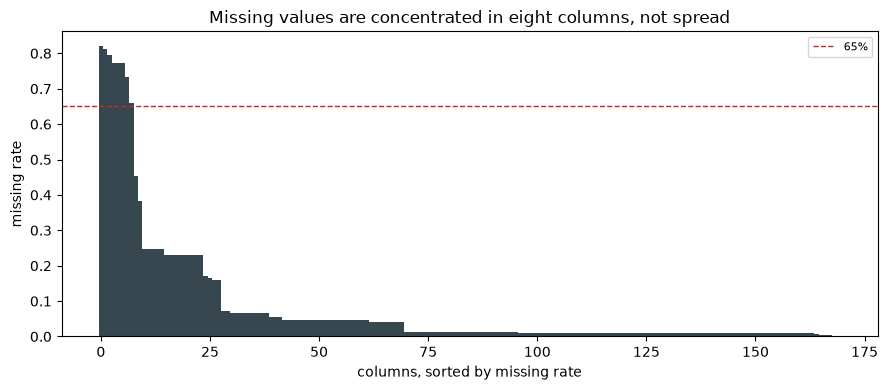

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ordered = rate.sort_values(ascending=False)
ax.bar(range(len(ordered)), ordered.values, width=1.0, color='#37474f')
ax.axhline(0.65, color='#c62828', lw=1, ls='--', label='65%')
ax.set_xlabel('columns, sorted by missing rate')
ax.set_ylabel('missing rate')
ax.set_title('Missing values are concentrated in eight columns, not spread')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '00_missing_distribution.png', dpi=150)

The 8.3% average and the per-column reading describe two different datasets. Eight
columns sit above 65%, one column is complete, and the rest are nearly full. The
selection grid's first version scored missingness on the average alone and would have
given this file the best possible mark. A second indicator was added: the number of
columns past a high threshold.

In [5]:
test_rate = scania['test'].drop(columns=[TARGET]).isna().mean()
profile = pd.DataFrame({'training': rate, 'test': test_rate})
print('largest gap between the two files :',
      f"{(profile['training'] - profile['test']).abs().max():.4f}")
print('  a near-zero maximum indicates a homogeneous collection')

largest gap between the two files : 0.0055
  a near-zero maximum indicates a homogeneous collection


## 2. The two rejected candidates

Each was eliminated for a different reason, and only one of the two was eliminated by
the scoring grid. The other failed an eliminating filter.

In [6]:
metro_path = RAW_DIR / 'metropt-3' / 'MetroPT3-AirCompressor.csv'
engine_path = RAW_DIR / 'engine-health' / 'engine_data.csv'

metro = pd.read_csv(metro_path) if metro_path.exists() else None
engine = pd.read_csv(engine_path) if engine_path.exists() else None
print('MetroPT-3    :', metro.shape if metro is not None else 'not on disk')
print('Engine Health:', engine.shape if engine is not None else 'not on disk')

MetroPT-3    : (1516948, 17)
Engine Health: (19535, 7)


### MetroPT-3: no target column

1 516 948 rows at 1 Hz over seven months, 15 named sensors, and no label. What the
producer supplies separately is a table of four air-leak reports with start and end
timestamps. Building a target would mean deciding which rows fall inside those windows,
which is a preparation step whose outcome would condition the whole project.

The grid's "usable labelling" filter is eliminating. This candidate fails at the first
stage and is never scored.

In [7]:
if metro is not None:
    print('columns :', list(metro.columns))
    print('period  :', metro['timestamp'].min(), 'to', metro['timestamp'].max())
    print('missing :', f"{metro.isna().mean().mean():.4%}")
    print('any column that could be a label :',
          [c for c in metro.columns if 'fail' in c.lower() or 'label' in c.lower()
           or 'class' in c.lower() or 'anomal' in c.lower()])

columns : ['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']
period  : 2020-02-01 00:00:00 to 2020-09-01 03:59:50
missing : 0.0000%
any column that could be a label : []


### Engine Health: not an automotive dataset, and no imbalance

Two findings, in order of importance.

**The file is a ship's main engine, not a road vehicle.** The Kaggle dataset titled
"Automotive Vehicles Engine Health" matches, column for column and down to the file
size, an IEEE DataPort deposit of November 2022 describing marine propulsion. The
automotive name is a relabelling, and it removed the project's only fallback inside the
automotive domain. A distribution platform is not a source.

**There is no class imbalance.** 63/37, against 1.67% positives for Scania. Class
imbalance is one of the three difficulties the project exists to handle, and this
candidate does not present it. That is what decided the scoring: 12 points against 34.

The first version of the grid eliminated this candidate at the first stage, on a
reservation entered against "real data". That was wrong. The data is real, measured on a
real engine; the three objections raised all belonged to the second stage. The candidate
was reinstated at the first stage and then lost on the score.

In [8]:
if engine is not None:
    print(engine['Engine Condition'].value_counts(normalize=True).round(4).to_string())
    print('\nmissing :', f"{engine.isna().mean().mean():.4%}")
    print('columns :', list(engine.columns))
    print('\nThe meaning of the two label values is not documented by the producer;',
          '\n0 = normal is the convention used by third-party republications and is',
          '\ntreated here as an unverified assumption.')

Engine Condition
1    0.6305
0    0.3695

missing : 0.0000%
columns : ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp', 'Engine Condition']

The meaning of the two label values is not documented by the producer; 
0 = normal is the convention used by third-party republications and is 
treated here as an unverified assumption.


## 3. The three candidates side by side

The comparison that matters is not size. It is which file carries the three difficulties
the project is about: a rare class, structured missingness, and an asymmetric cost.

In [9]:
summary = pd.DataFrame([
    {'candidate': 'APS Scania', 'rows': len(scania['training']),
     'columns': scania['training'].shape[1] - 1,
     'minority_share': scania['training'][TARGET].mean(),
     'missing': scania['training'].isna().mean().mean(),
     'labelled': True, 'cost_matrix': True, 'domain': 'heavy road vehicle'},
    {'candidate': 'MetroPT-3',
     'rows': len(metro) if metro is not None else np.nan,
     'columns': (metro.shape[1] - 1) if metro is not None else np.nan,
     'minority_share': np.nan,
     'missing': metro.isna().mean().mean() if metro is not None else np.nan,
     'labelled': False, 'cost_matrix': False, 'domain': 'railway'},
    {'candidate': 'Engine Health',
     'rows': len(engine) if engine is not None else np.nan,
     'columns': (engine.shape[1] - 1) if engine is not None else np.nan,
     'minority_share': (engine['Engine Condition'].value_counts(normalize=True).min()
                        if engine is not None else np.nan),
     'missing': engine.isna().mean().mean() if engine is not None else np.nan,
     'labelled': True, 'cost_matrix': False, 'domain': 'marine, not automotive'},
]).set_index('candidate')
summary.round(4)

,rows,columns,minority_share,missing,labelled,cost_matrix,domain
candidate,,,,,,,
APS Scania,60000,170,0.0167,0.0828,True,True,heavy road vehicle
MetroPT-3,1516948,16,NaN,0.0000,False,False,railway
Engine Health,19535,6,0.3695,0.0000,True,False,"marine, not automotive"


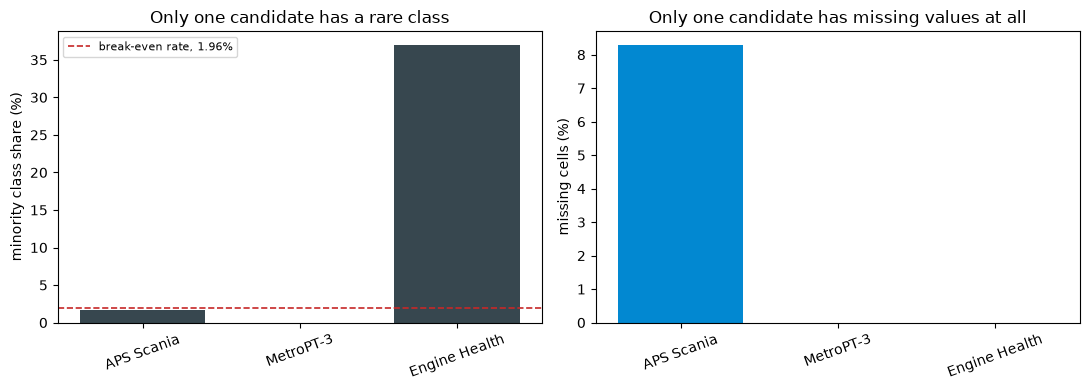

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = summary.index.tolist()

axes[0].bar(order, summary['minority_share'].fillna(0) * 100, color='#37474f')
axes[0].axhline(1.96, color='#c62828', lw=1.2, ls='--',
                label='break-even rate, 1.96%')
axes[0].set_ylabel('minority class share (%)')
axes[0].set_title('Only one candidate has a rare class')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)

axes[1].bar(order, summary['missing'].fillna(0) * 100, color='#0288d1')
axes[1].set_ylabel('missing cells (%)')
axes[1].set_title('Only one candidate has missing values at all')
axes[1].tick_params(axis='x', rotation=20)

fig.tight_layout()
fig.savefig(FIGURES_DIR / '00_candidate_comparison.png', dpi=150)

## 4. Is the cost metric here the same as the published one?

This is the step that makes every cost figure in this repository comparable to the
literature rather than merely internally consistent.

The producer announced the top three results of the 2016 challenge together with the
detail of their errors. Recomputing the totals from that detail, with the 10 and 500
rule, either reproduces the announced totals exactly or it does not.

One trap on the way: the source names the two error types "type 1" and "type 2". Read
the wrong way round, the third result recomputes to 199 150 instead of 11 480. The
recomputation is what caught it.

In [11]:
from src.cost import constant_rule_costs, total_cost

N_TEST, N_POSITIVE = 16_000, 375

published = pd.DataFrame([
    {'team': 'Costa, Nascimento', 'announced': 9_920, 'FP': 542, 'FN': 9},
    {'team': 'Gondek, Hafner, Sampson', 'announced': 10_900, 'FP': 490, 'FN': 12},
    {'team': 'Garnaik, Das, Sreepada, Patra', 'announced': 11_480, 'FP': 398, 'FN': 15},
])

y_test = np.r_[np.ones(N_POSITIVE, int), np.zeros(N_TEST - N_POSITIVE, int)]

def rebuild(fp, fn):
    tp = N_POSITIVE - fn
    return np.r_[np.ones(tp, int), np.zeros(fn, int),
                 np.ones(fp, int), np.zeros(N_TEST - N_POSITIVE - fp, int)]

published['recomputed'] = [total_cost(y_test, rebuild(r.FP, r.FN))
                           for r in published.itertuples()]
published['match'] = published['announced'] == published['recomputed']
assert published['match'].all()
published

,team,announced,FP,FN,recomputed,match
0,"Costa, Nascimento",9920,542,9,9920,True
1,"Gondek, Hafner, Sampson",10900,490,12,10900,True
2,"Garnaik, Das, Sreepada, Patra",11480,398,15,11480,True


The three totals land to the unit. The cost rule used in this project is the challenge's
rule, applied to the same test file, so the comparison is legitimate.

The same detail also yields two figures the teams did not publish: their detection rate
and the share of their alerts that were justified.

In [12]:
published['recall'] = (N_POSITIVE - published['FN']) / N_POSITIVE
published['precision'] = ((N_POSITIVE - published['FN'])
                          / (N_POSITIVE - published['FN'] + published['FP']))
reference = constant_rule_costs(y_test)['reference']
published['share_of_reference'] = published['announced'] / reference
published[['team', 'announced', 'recall', 'precision',
           'share_of_reference']].round(4)

,team,announced,recall,precision,share_of_reference
0,"Costa, Nascimento",9920,0.976,0.4031,0.0635
1,"Gondek, Hafner, Sampson",10900,0.968,0.4256,0.0698
2,"Garnaik, Das, Sreepada, Patra",11480,0.960,0.4749,0.0735


## 5. The reference to beat, and why it flips

Two constant rules are available, and the cheaper of the two is the reference. Which one
wins is not a property of the problem: it depends on whether the positive rate sits
above or below the 1.96% break-even rate. It therefore differs between the official test
file and any split of the training file.

Anyone quoting a single reference number for this dataset has to say which file it is
measured on.

In [13]:
for name, frame in scania.items():
    rules = constant_rule_costs(frame[TARGET])
    print(f'{name}  positive rate {rules["positive_rate"]:.4%}',
          f"(break-even {rules['break_even_rate']:.4%})")
    print(f'  never-flag  {rules["never_flag"]:>8,}')
    print(f'  always-flag {rules["always_flag"]:>8,}')
    print(f'  reference   {rules["reference"]:>8,}  <- {rules["cheaper"]}\n')

training  positive rate 1.6667% (break-even 1.9608%)
  never-flag   500,000
  always-flag  590,000
  reference    500,000  <- never_flag

test  positive rate 2.3438% (break-even 1.9608%)
  never-flag   187,500
  always-flag  156,250
  reference    156,250  <- always_flag



The contract sets the objective at half the reference. Decomposing that objective is
what showed it to be a floor rather than a target: a model that detects 90% of failures
misses 38 of them, which consumes 19 000 of the budget, and the remainder pays for about
5 900 false alarms. Such a model would have 94.6% of its alerts wrong, which no workshop
would use.

Three levels were proposed in its place: an acceptability floor at half the reference, a
working target at 20 000, and an excellence level at 10 000.

In [14]:
from src.config import COST_FN, COST_FP

budget = reference / 2
detected = 0.90
missed = int(round(N_POSITIVE * (1 - detected)))
spent_on_misses = COST_FN * missed
affordable_alarms = int((budget - spent_on_misses) / COST_FP)
true_alerts = int(round(N_POSITIVE * detected))

print(f'contractual budget          : {budget:>10,.0f}')
print(f'90% detection misses        : {missed} failures = {spent_on_misses:,}')
print(f'remaining false alarms      : {affordable_alarms:,}')
print(f'share of alerts that are wrong : '
      f'{affordable_alarms / (affordable_alarms + true_alerts):.1%}')

contractual budget          :     78,125
90% detection misses        : 37 failures = 18,500
remaining false alarms      : 5,962
share of alerts that are wrong : 94.6%


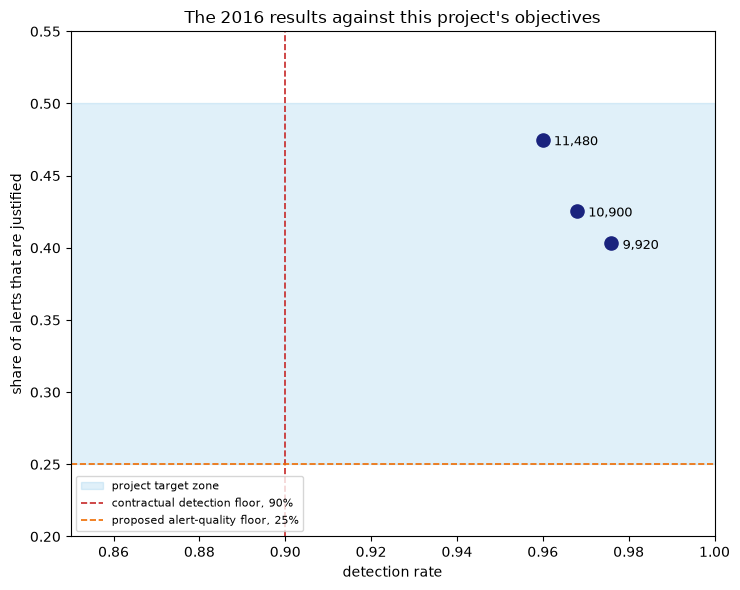

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6))

ax.axhspan(0.25, 0.50, xmin=0, xmax=1, color='#0288d1', alpha=0.12,
           label='project target zone')
ax.axvline(0.90, color='#c62828', lw=1.2, ls='--',
           label='contractual detection floor, 90%')
ax.axhline(0.25, color='#ef6c00', lw=1.2, ls='--',
           label='proposed alert-quality floor, 25%')
ax.scatter(published['recall'], published['precision'], s=90,
           color='#1a237e', zorder=3)
for r in published.itertuples():
    ax.annotate(f'{r.announced:,}', (r.recall, r.precision),
                xytext=(8, -4), textcoords='offset points', fontsize=9)

ax.set_xlim(0.85, 1.0)
ax.set_ylim(0.20, 0.55)
ax.set_xlabel('detection rate')
ax.set_ylabel('share of alerts that are justified')
ax.set_title('The 2016 results against this project\'s objectives')
ax.legend(loc='lower left', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '00_state_of_the_art.png', dpi=150)

## What comes out of this notebook

**APS Scania is the only candidate that carries the three difficulties.** MetroPT-3 has
no label and fails an eliminating filter; Engine Health has no imbalance, no missing
values, no cost matrix, and is not in the announced domain.

**The cost rule is verified, not assumed.** The three published totals recompute to the
unit from their error counts, on the same test file.

**The reference to beat depends on the file.** 156 250 on the test file, where flagging
everything wins; 100 000 on a 12 000 row split of the training file, where flagging
nothing wins. The break-even rate of 1.96% is what separates the two cases.

**The contractual objective is a floor, not a target.** Decomposed, it accepts a model
whose alerts are 94.6% wrong.

**A reservation to keep in mind.** The test answers have been public since 2016 and
published scores keep improving on that fixed file: 10 140 in 2018, 6 050 in 2019,
3 440 in 2024. This project opens the test file once, at the end, so it compares a blind
result against results whose independence is not guaranteed.